In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the cleaned dataset
df = pd.read_csv('sales_clean.csv')

# Verify the shape of the dataframe
print("Dataset Shape:", df.shape)

Dataset Shape: (292, 6)


In [2]:
# Price statistics
print("--- Price Statistics ---")
print("Mean:  ", df["price"].mean())
print("Median:", df["price"].median())
print("Std:   ", df["price"].std())

# Quantity statistics
print("\n--- Quantity Statistics ---")
print("Mean:  ", df["qty"].mean())
print("Median:", df["qty"].median())
print("Std:   ", df["qty"].std())

--- Price Statistics ---
Mean:   55.52315068493151
Median: 37.53
Std:    71.76708493504132

--- Quantity Statistics ---
Mean:   2.910958904109589
Median: 3.0
Std:    1.559457271336151


I would report the median for the price metric because there is a noticeable gap between the mean (~55.52) and the median (37.53). This indicates that the dataset is highly skewed by extreme values or luxury items. The median provides a more honest headline representing the typical customer transaction without being dragged upward by high-priced outliers.


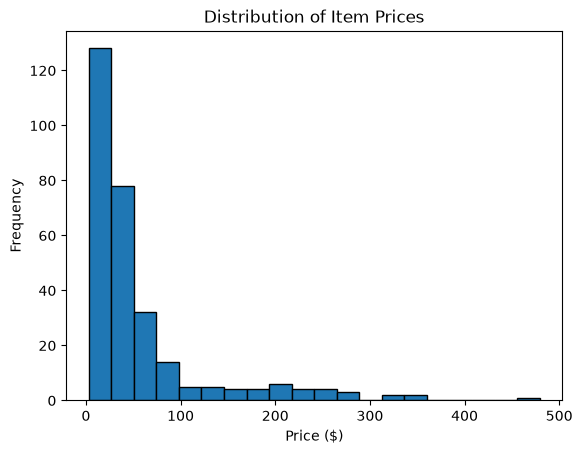

In [3]:
df["price"].plot(kind="hist", bins=20, edgecolor='black')
plt.title("Distribution of Item Prices")
plt.xlabel("Price ($)")
plt.ylabel("Frequency")
plt.show()

The price distribution histogram is strictly right-skewed with a long tail extending toward more expensive items.

In [4]:
df["revenue"] = df["price"] * df["qty"]
df.head()

,order_id,date,product,price,qty,zip,revenue
0,1254,2026-04-06,mug,11.36,4,60614,45.44
1,1057,2026-05-30,charger,14.79,3,30303,44.37
2,1150,2026-05-06,mug,5.50,1,10001,5.50
3,1066,2026-05-30,notebook,37.53,1,98101,37.53
4,1114,2026-04-06,webcam,45.59,4,90405,182.36


In [5]:
df.corr(numeric_only=True)

,order_id,price,qty,zip,revenue
order_id,1.000000,-0.005070,0.024140,-0.014784,0.005711
price,-0.005070,1.000000,-0.023683,0.023812,0.817699
qty,0.024140,-0.023683,1.000000,0.074617,0.334196
zip,-0.014784,0.023812,0.074617,1.000000,0.044615
revenue,0.005711,0.817699,0.334196,0.044615,1.000000


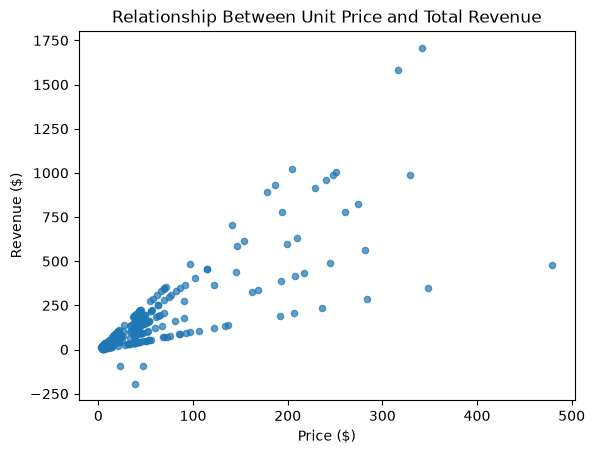

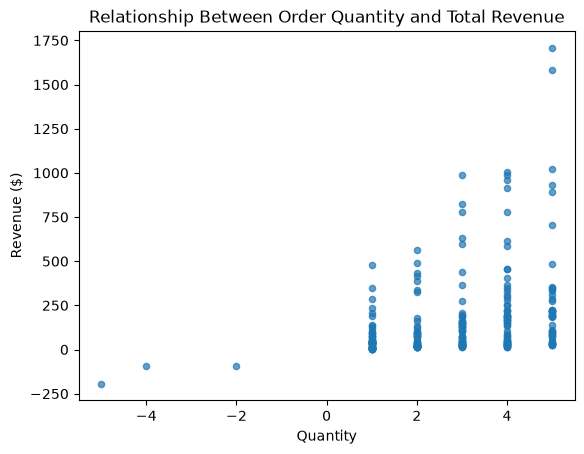

In [6]:
df.plot.scatter(x="price", y="revenue", alpha=0.7)
plt.title("Relationship Between Unit Price and Total Revenue")
plt.xlabel("Price ($)")
plt.ylabel("Revenue ($)")
plt.show()

df.plot.scatter(x="qty", y="revenue", alpha=0.7)
plt.title("Relationship Between Order Quantity and Total Revenue")
plt.xlabel("Quantity")
plt.ylabel("Revenue ($)")
plt.show()

The data demonstrates a strong positive linear relationship (r = 0.818) between an item's unit price and its generated transaction revenue, meaning higher-priced items dominate our total incoming sales. However, management should remain cautious because this trend is highly sensitive to a few expensive outliers (like high-end monitors), and there are entry errors in our records, including negative order quantities (e.g., order #1140 and #1233) that could skew our long-term baseline assumptions.

Dataset: \([2, 4, 4, 6, 9]\)
By-Hand Mean Calculation: \(\frac{2 + 4 + 4 + 6 + 9}{5} = \frac{25}{5} = \mathbf{5.0}\)
By-Hand Median Calculation: Sorted middle value at position index 2 is \[\mathbf{4}\]. 

In [7]:
import numpy as np

hand_check_data = [2, 4, 4, 6, 9]
print("Verified Mean:", np.mean(hand_check_data))
print("Verified Median:", np.median(hand_check_data))

Verified Mean: 5.0
Verified Median: 4.0
